# Converting photometry table from photometry tools to a light curve

-Example transit light curve of exoplanet WASP-36 b


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time
from astropy.io import fits
from astropy.visualization import ZScaleInterval, ImageNormalize

To create a light curve of your desired object (here we'll use the sample WASP-36 b data stored in the data directory), you must first run the `sort_observations.py` script, then `image_reduction_interact_select.py` (or `image_reduction.py`) with instructions for these included in the README file. 

Then you neet to perform photometry on the reduced images, using your method of choice, though the psf photometry tool in the photomety_analysis directory (either `psf_photometry.py` or `psf_photometry_intselect.py`) is optimized for running photometric calculations across multiple images that will allow you to view your data as a time series.


For this tutorial notebook, we will assume the user has ran the mentioned scripts, and saved the PSF_Photometry_Results to their Reduced data directory. 

## Reading in your photometric data

In [ ]:
path = '../data/WASP36b/Reduced/' #Replace with your own path to the data directory if needed

In [4]:
phot_table = pd.read_csv(path + 'PSF_Photometry_Results/WASP-36B_psf_photometry.csv')
phot_table

,File,BJD,Flux_Star_1,Flux_err_Star_1,Minst_Star_1,Minst_err_Star_1,Star_1_x,Star_1_y,Flux_Star_2,Flux_err_Star_2,...,Minst_Star_6,Minst_err_Star_6,Star_6_x,Star_6_y,Flux_Star_7,Flux_err_Star_7,Minst_Star_7,Minst_err_Star_7,Star_7_x,Star_7_y
0,WASP36B.2025-02-17.0130_reduced.fits,2.460725e+06,282287.058174,546.174940,-8.186499,0.002101,497,399,54047.117557,264.927780,...,-8.283969,0.002002,379,331,47220.391266,249.444758,-6.245096,0.005735,400,354
1,WASP36B.2025-02-17.0131_reduced.fits,2.460725e+06,276223.552607,543.159044,-8.162924,0.002135,497,399,52597.195288,267.773552,...,-8.260781,0.002034,379,331,44585.431397,247.583142,-6.182754,0.006029,400,354
2,WASP36B.2025-02-17.0132_reduced.fits,2.460725e+06,291172.857882,560.321511,-8.220149,0.002089,497,399,54788.108351,278.886538,...,-8.323706,0.001987,379,331,47775.484656,263.461669,-6.257785,0.005987,400,354
3,WASP36B.2025-02-17.0133_reduced.fits,2.460725e+06,300142.663636,569.830374,-8.253091,0.002061,497,399,56524.546061,283.859529,...,-8.349957,0.001964,379,331,46227.321709,260.195894,-6.222019,0.006111,400,354
4,WASP36B.2025-02-17.0134_reduced.fits,2.460725e+06,288146.853113,554.147136,-8.208807,0.002088,497,399,53893.884594,269.733358,...,-8.309209,0.001987,379,331,47850.882942,255.447281,-6.259497,0.005796,400,354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,WASP36B.2025-02-17.0192_reduced.fits,2.460725e+06,268471.314830,538.256080,-8.132017,0.002177,497,399,50700.660994,267.429678,...,-8.227850,0.002075,379,331,42720.885770,249.836282,-6.136372,0.006350,400,354
62,WASP36B.2025-02-17.0193_reduced.fits,2.460725e+06,268018.205481,536.161003,-8.130183,0.002172,497,399,50918.594233,265.376143,...,-8.221244,0.002076,379,331,43900.823805,249.078592,-6.165954,0.006160,400,354
63,WASP36B.2025-02-17.0194_reduced.fits,2.460725e+06,261758.224207,530.127765,-8.104523,0.002199,497,399,49587.297424,262.301865,...,-8.198747,0.002098,379,331,42499.389718,244.998066,-6.130729,0.006259,400,354
64,WASP36B.2025-02-17.0195_reduced.fits,2.460725e+06,258392.305390,527.937590,-8.090471,0.002218,497,399,48732.829648,262.427746,...,-8.178892,0.002122,379,331,40725.540005,242.772664,-6.084439,0.006472,400,354


If you'd like to reproduce the following results using the photometry tool, I'll show from my photometry table which reference stars I selected (X's). While your target should hopefully be in the center of your frame, you may need to cross-reference the logbook or Finder images to verify this

In [5]:
N_refs = 6 #Adjust to your number of reference stars

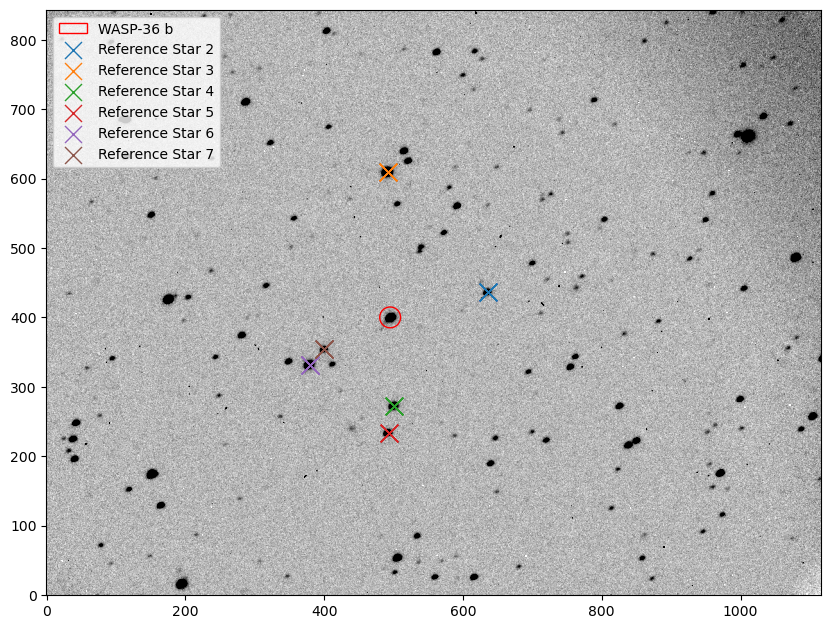

In [27]:
plt.figure(figsize=(10, 10))
first_image = fits.getdata(path+'WASP-36B/WASP36B.2025-02-17.0130_reduced.fits')
plt.imshow(first_image, origin='lower', cmap='gray_r', norm=ImageNormalize(first_image, interval=ZScaleInterval()))
circle = plt.Circle((495, 400), radius=15, color='red', fill=False, label='WASP-36 b')
plt.gca().add_patch(circle)
# plt.scatter(phot_table['Star_1_x'], phot_table['Star_1_y'], marker='x',s=0) #To keep colors consistent for the next plot
for i in range(1,N_refs+1): #Assuming Star 1 is your target
    plt.scatter(phot_table[f'Star_{i+1}_x'], phot_table[f'Star_{i+1}_y'], marker='x',s=150,linewidths=1,label=f'Reference Star {i+1}')
plt.legend(loc='upper left')
plt.show()

Lets plot the raw light curves of our objects. 

Here the BJD column is time, and for the timeseries we'll be using flux rather than magnitudes for our target and reference stars. 

It is typically recommended to choose your target star as star 1 when running the psf photometry tool, and I'd recommend at least 3 or more reference stars for generating a clean light curve (here I've initally selected 6). This can vary depending on the quality of your observations and choice of stars, as some stars may have their own variable signatures that will contaminate the target light curve upon correcting. 

I recommend choosing reference stars that are similar in magnitude to your target, close in proximity on the image to your target (to avoid faulty calibrations - like the dark region in the upper right of this image) and stars with low or minimal variability of their own. We'll see how to identify that last problem in a few steps. 


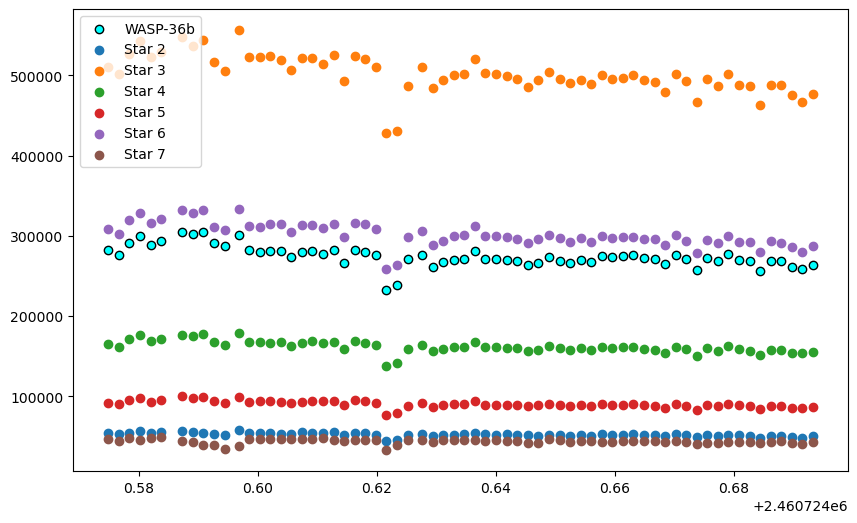

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(phot_table['BJD'], phot_table['Flux_Star_1'], label='WASP-36b',color='cyan',edgecolor='black')

for i in range(1,N_refs+1): #Assuming Star 1 is your target plot each of your reference stars
    plt.scatter(phot_table['BJD'],phot_table[f'Flux_Star_{i+1}'],label=f'Star {i+1}')
    plt.legend()    

### Reference star inspection

It's also useful to check each reference star's flux divided by the combined flux of the *other* reference stars. A good reference star should produce a relatively flat ratio over time; one that shows its own trend or variability may be contaminating the corrected target light curve and could be worth excluding.

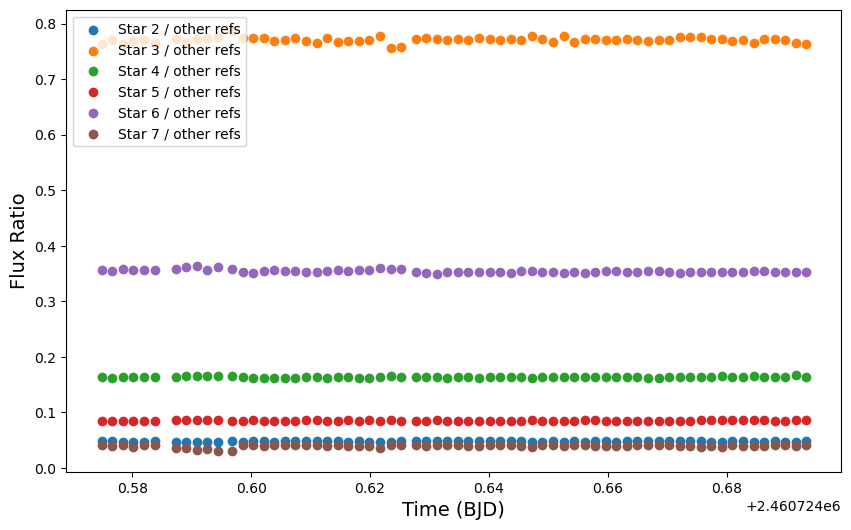

In [8]:
plt.figure(figsize=(10, 6))

for i in range(1, N_refs+1): #Assuming Star 1 is your target
    other_stars = [j for j in range(1, N_refs+1) if j != i]
    other_flux_combined = np.sum([phot_table[f'Flux_Star_{j+1}'] for j in other_stars], axis=0)
    ref_ratio = phot_table[f'Flux_Star_{i+1}'] / other_flux_combined
    plt.scatter(phot_table['BJD'], ref_ratio, label=f'Star {i+1} / other refs')

plt.xlabel('Time (BJD)', fontsize=14)
plt.ylabel('Flux Ratio', fontsize=14)
plt.legend()
plt.show()

With a lot of reference stars it can get hard to spot the noisy ones by eye. Computing RMS on the flux *ratios* above has a downside: every star's ratio (except its own) still includes every other star, including a noisy one, in its denominator — so one bad star can inflate everyone else's apparent RMS too, potentially masking the real culprit.

Instead, we can check each star's own light curve in isolation: normalize each star's flux by its own median and look at the RMS of that.

RMS naturally rises for fainter stars (less signal, more photon noise), so a raw RMS number isn't meaningful on its own — a faint star with "high" RMS may just be faint, and a bright star with "low" RMS may just be bright. Plotting RMS against instrumental magnitude for all reference stars lets you judge each one relative to stars of similar brightness: one that sits noticeably above the general trend for its magnitude is a better candidate to flag than one judged on RMS alone. It's also a quick way to see which reference stars are closest in brightness to your target, which is generally preferable since they'll share more comparable noise behavior.

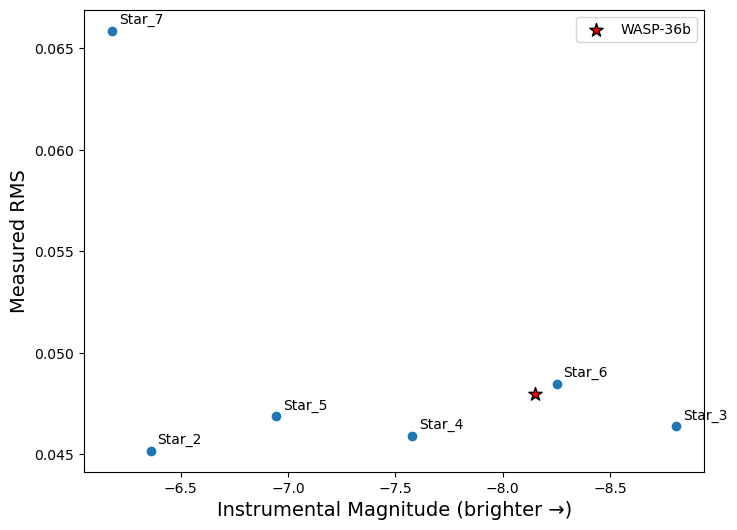

In [29]:
mags, rmss, labels = [], [], []
for i in range(1, N_refs+1): #Assuming Star 1 is your target
    flux = phot_table[f'Flux_Star_{i+1}']
    norm_flux = flux / np.median(flux)
    rmss.append(np.sqrt(np.mean((norm_flux - 1)**2)))
    mags.append(np.median(phot_table[f'Minst_Star_{i+1}']))
    labels.append(f'Star_{i+1}')

    
plt.figure(figsize=(8, 6))
plt.scatter(np.median(phot_table['Minst_Star_1']), np.sqrt(np.mean((phot_table['Flux_Star_1']/np.median(phot_table['Flux_Star_1']) - 1)**2)), label='WASP-36b', color='r', edgecolor='black', marker='*', s=100)

plt.scatter(mags, rmss)
for mag, rms, label in zip(mags, rmss, labels):
    plt.annotate(label, (mag, rms), textcoords='offset points', xytext=(5, 5))
plt.legend()
plt.xlabel('Instrumental Magnitude (brighter →)', fontsize=14)
plt.ylabel('Measured RMS', fontsize=14)
plt.gca().invert_xaxis() #brighter (more negative Minst) stars on the right
plt.show()

Clearly we have at least one outlier here, but we'll come back to that in a moment. 


### Correcting and plotting your light curve
To correct your targets light curve you will want to divide your target star's flux by some combination of reference star fluxes. I usually test using all of them first, then I'll test how different combinations affect the shape of the resulting light curve to inform decisions about which reference stars to include or exclude.

In [11]:
ref_flux = np.array([phot_table[f'Flux_Star_{i+1}'] for i in range(1,N_refs+1)]) #Assuming Star 1 is your target
ref_err = np.sqrt(np.sum(np.array([phot_table[f'Flux_err_Star_{i+1}']**2 for i in range(1,N_refs+1)]), axis=0)) #Don't forget to include errors on your measurements
ref_flux_combined = np.sum(ref_flux, axis=0) 

In [12]:
wasp36_flux = phot_table['Flux_Star_1'] / ref_flux_combined
# simple error propagation for the flux ratio
wasp36_err = wasp36_flux*np.sqrt((phot_table['Flux_err_Star_1']/phot_table['Flux_Star_1'])**2 + (ref_err/ref_flux_combined)**2)

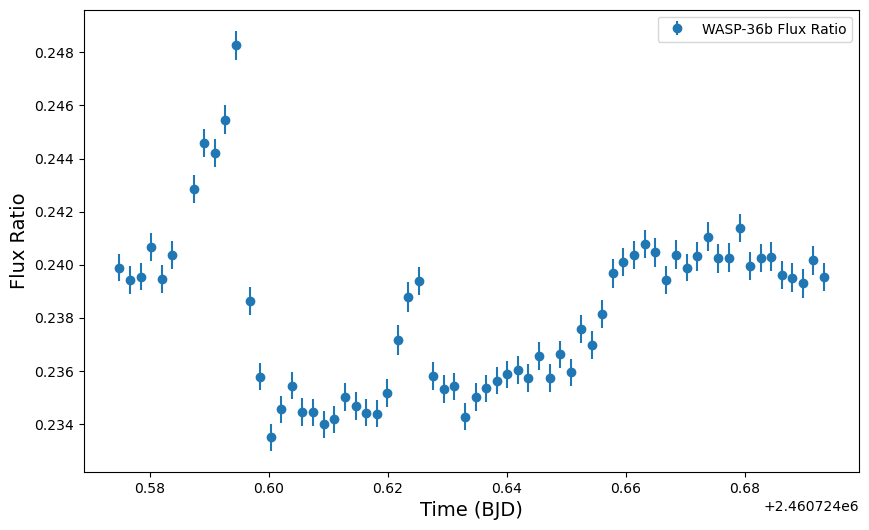

In [13]:
plt.figure(figsize=(10, 6))
plt.errorbar(phot_table['BJD'], wasp36_flux, yerr=wasp36_err, label='WASP-36b Flux Ratio', fmt='o')
plt.xlabel('Time (BJD)',fontsize=14)
plt.ylabel('Flux Ratio',fontsize=14)
plt.legend()
# plt.ylim(0.132,0.142)

Great! I'd say this looks fairly "transit-y" despite some outliers in a couple areas. You could probably do some outlier removal and call this good if you felt like it at this point. There's a clear ingress, in-transit and egress section of the light curve.  

Looking back at the full reference star light curves, because we see those same features (the spike near planet ingress and spike near mid-transit) in each of the reference star light curves and how they appear to correlate with star magnitude, we can assume these variations are largely instrumental or systematic (not astrophysical). 

However in looking at the RMS vs Magnitude plot of our reference stars relative to the target: Star 7 is clearly an outlier in our sample of reference stars, and star 2 (or my measurement of it) shows it being much fainter than our target, so I'll try excluding those one at a time. (I might even exclude 5 due to its large magnitude offset as well)

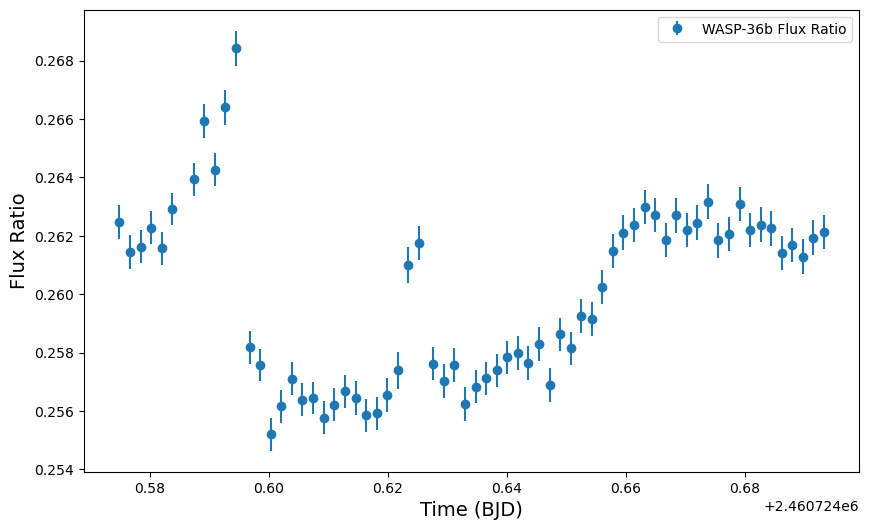

In [44]:
refs = [3,4,5,6] #Adjust to your preferred reference stars
select_ref_flux = np.array([phot_table[f'Flux_Star_{i}'] for i in refs])
select_ref_err = np.sqrt(np.sum(np.array([phot_table[f'Flux_err_Star_{i}']**2 for i in refs]),axis=0))
select_ref_flux = select_ref_flux.sum(axis=0)
test_wasp36_flux = phot_table['Flux_Star_1'] / select_ref_flux
# simple error propagation for the flux ratio
select_wasp36_err = test_wasp36_flux*np.sqrt((phot_table['Flux_err_Star_1']/phot_table['Flux_Star_1'])**2 + (select_ref_err/select_ref_flux)**2)
plt.figure(figsize=(10, 6))
plt.errorbar(phot_table['BJD'], test_wasp36_flux, yerr=select_wasp36_err, label='WASP-36b Flux Ratio', fmt='o')
plt.xlabel('Time (BJD)',fontsize=14)
plt.ylabel('Flux Ratio',fontsize=14)
plt.legend()
# plt.ylim(1.14,1.25)

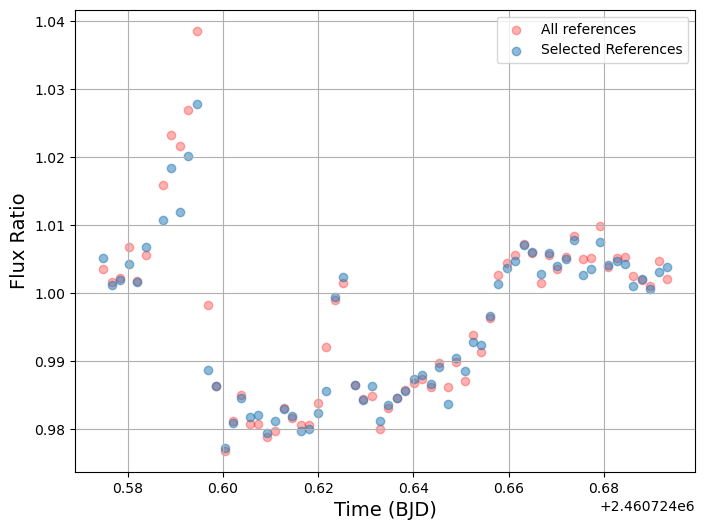

In [45]:
plt.figure(figsize=(8, 6))
plt.scatter(phot_table['BJD'], wasp36_flux/np.median(wasp36_flux), label='All references',color='r',alpha=0.3)
plt.scatter(phot_table['BJD'], test_wasp36_flux/np.median(test_wasp36_flux),  label='Selected References',alpha=0.5)
plt.xlabel('Time (BJD)',fontsize=14)
plt.ylabel('Flux Ratio',fontsize=14)
plt.legend() 
plt.grid()

Not a huge difference, but it calmed down the base near mid-transit some (excluding some probably very bright couple of frames) and settled the noise going on around the ingress a bit, so I'll stick with this version instead over my original sample of reference stars.

If things are still looking wrong, its at this point where you may consider going back to redo the photometry, especially if you feel like too many of your reference stars were bad choices and needed to be left out. I won't even mention how many times I did that while creating this notebook. Keep in mind you'll usually want enough to perform a good correction (usually $\geq 3$). 


Sometimes your observations just weren't great: there were clouds, the telescope drifted, somebody forgot to take flats, or you had weird light variations across the detector. Or the reduction/analysis failed: You didn't select the whole star with the psf tool, the background subtraction did poorly. For some of these issues, no amount or combination of reference stars can save you. This is good to remember and its okay if things don't look like a Kepler transit light curve or a variable star light curve from TESS. 